# Graph-based functional connectivity

---

Bulllmore&Sporns 2009 https://www.nature.com/articles/nrn2575

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alanturin-g/Computational_Neuroscience_UNITO/blob/main/Borriero_2_seed_based_functional_connectivity.ipynb)

# Importing

In [ ]:
! pip install nibabel nilearn nitime statsmodels seaborn pycirclize networkx community itertools

In [1]:
import nilearn as nil
import nibabel as nib
import numpy as np
import pandas as pd
import os
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import plotting, surface, datasets, input_data, decomposition
from scipy.stats import pearsonr, spearmanr
from tqdm import tqdm # For having progressbar during loops
from nitime.timeseries import TimeSeries
from nitime.analysis import FilterAnalyzer
from sklearn.decomposition import PCA
from nilearn.connectome import ConnectivityMeasure
from matplotlib import colors
from matplotlib import patches
from pycirclize import Circos
import sys
import networkx as nx
import community as community_louvain
from networkx.algorithms.community.centrality import girvan_newman
from statannotations.Annotator import Annotator
from itertools import combinations



# Download some files

In [ ]:
# A wrapper method to download files

import os, subprocess, shlex
import os
import subprocess

def download_from_drive(file_keyword, base_folder="."):
    file_name, file_ID = files_dict[file_keyword]
    DEST_PATH = os.path.join(base_folder, file_name)
    if not os.path.exists(DEST_PATH):
        URL = f"https://drive.usercontent.google.com/download?id={file_ID}&confirm=t"
        cmd = ["wget", "-q", "--show-progress", "--progress=bar:force:noscroll",
            "--no-check-certificate", "-O", DEST_PATH, URL]
        ret = subprocess.call(cmd)  # shell=False by default
        if ret != 0:
            raise RuntimeError("Download failed. Check sharing settings or FILE_ID.")
        else:
            print("Downloaded " + file_name + "!")
    else:
        print(file_name + " already present:", DEST_PATH)

In [ ]:
files_dict = {'glasser_labels' : ('glasser_labels.csv','12LumqrRkp1rUAJGg8h3tOIwWubhyyoqY'),
              'glasser_atlas':   ('glasser_atlas.nii.gz','1GeB5pi25SRnyit8s5siDUCFFmJfsB3Yw'),
              'schaefer_labels': ('schaefer_labels.csv', '1Lgh4X9hud2xXGxYEWADFxfMe81P_tTfS'),
              'schaefer_atlas':  ('schaefer_atlas.nii.gz', '1acSTf6m9TyJxm2ruTcwd9eC8PNGfG1PX'),
              'subj_01_rest':  ('subj_01_rest.nii.gz', '1XXhVrMymlaBE0ekbgbHoH8fVYteWFGIa'),
              'subj_03_rest':  ('subj_03_rest.nii.gz', '1RziRBrPUFemlHfjPMoeJX26CbHhqlKM4'),
              'subj_04_rest':  ('subj_04_rest.nii.gz', '10thmeWWgk31FaBk0Qi0n_rtOef5YVAjM'),
              'subj_05_rest':  ('subj_05_rest.nii.gz', '1-_ifL8yQWAoUiU7v7niz6O9YbVGyj4xn'),
              'subj_06_rest':  ('subj_06_rest.nii.gz', '1iE-5pfybf8imraDfJvP6A-XuXIyHVHQD'),
              'subj_01_sleep':  ('subj_01_sleep.nii.gz', '1zAU1sI9jS0wzGp_raNUemxUYPilLIZJH'),
              'subj_03_sleep':  ('subj_03_sleep.nii.gz', '1C9pPi7PwTcdg4Nfz1xVVCFToghRTxSQQ'),
              'subj_04_sleep':  ('subj_04_sleep.nii.gz', '1fn6xCluS7lEasPKgHafThwvhA11Mo0A5'),
              'subj_05_sleep':  ('subj_05_sleep.nii.gz', '1DkWrsAa3-jLtVggLIujtxNfqhgwezhea'),
              'subj_06_sleep':  ('subj_06_sleep.nii.gz', '1PvG2KQMF40QnmNs6Z5kMx8abKk_tBH3C'),
              'all_subj_mask':  ('000_all_subj_mask.nii.gz', '1azzh7yXC4uG8clHv4Zm7sBZgta0dTMDf')}

In [ ]:
for key in files_dict.keys():
  download_from_drive(key)

# Utils

In [2]:
def signal_filter(nifti_img, mask, standardize=False, ub=0.08, lb=0.008):
    print('Filtering the signal...')
    img = nifti_img.get_fdata()
    img_affine = nifti_img.affine
    TR = nifti_img.header.get_zooms()[3]
    
    n_vox_mask = np.sum(mask==1) # Number of voxels in the mask
    mask_cord = np.where(mask==1)
    img_filtered = np.zeros(img.shape)
#     print(img_filtered.shape)
    for v in tqdm(range(n_vox_mask)):
        voxel_ts = img[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
        T = TimeSeries(voxel_ts.T, sampling_interval=TR)
        F = FilterAnalyzer(T, ub=0.08, lb=0.008) #0.08, 0.008
        tmp_TC_filt = F.filtered_boxcar.data
        tmp_TC_filt = tmp_TC_filt.T
        if standardize:
            tmp_TC_filt = (tmp_TC_filt-np.mean(tmp_TC_filt))/np.std(tmp_TC_filt)
            
        # Check if there are nan values
        if np.sum(np.isnan(tmp_TC_filt))!=0:
            for t in tmp_TC_filt:
                tmp_TC_filt[t] = 0
        img_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] = tmp_TC_filt

    return nib.Nifti1Image(img_filtered, img_affine)

NetworkX documentation:
https://networkx.org/documentation/stable/index.html

In [3]:
# Undirected Graph metrics
def modularity_louvain(graph):
    # Detect the best partition
    partition = community_louvain.best_partition(graph, randomize=False)
    # Calculate modularity
    modularity_score = community_louvain.modularity(partition, graph)
    return modularity_score

def graph_metrics(METRIC, graph):
    edges_full = 345*345
    if METRIC=='number_connected_components':
        metric = nx.number_connected_components(graph) # number of connected components
    elif METRIC=='size_giant_component':
        metric = len(sorted(nx.connected_components(graph), key=len, reverse=True)[0]) # size giant component
    elif METRIC=='average_shortest_path':
        GiantComponent = graph.subgraph(sorted(nx.connected_components(graph), key=len, reverse=True)[0]).copy()                    
        metric = nx.average_shortest_path_length(GiantComponent) # Average shortest path inside the giant component
    elif METRIC=='global_average_shortest_path':
        sps = [list(nx.shortest_path_length(graph.subgraph(cc).copy())) for cc in nx.connected_components(graph)]
        global_sps = []
        for sp in sps:
            for l in sp:
                global_sps += list(l[1].values())
        metric = np.mean(global_sps) # Average shortest path (global)
    elif METRIC=='fraction_of_edges':
        edges = graph.number_of_edges()
        metric = edges/edges_full # fraction of remaining edges inside the graph
    elif METRIC=='node_wih_link':
        nodes = len([n for n in graph.nodes if len(list(graph.neighbors(n))) > 0])
        metric = nodes/nodes_full # node with at least a link
    #                 centr = nx.betweenness_centrality(GiantComponent)
    #                 max_centr_key = max(centr, key=centr.get)
    #                 max_centr = centr[max_centr_key]
    #                 metric = max_centr
    #                 metric = nx.betweenness_centrality(graph)[node] # centrality of a selected node
    #             print(metric)
    elif METRIC=='degree_distribution':
        d = sorted((d for n, d in graph.degree() if d!=0), reverse=True) # degree distribution
    elif METRIC=='average_degree':
        metric = np.mean([d for n, d in graph.degree() if d!=0])
    elif METRIC=='average_local_efficiency':
        metric = nx.local_efficiency(graph)
    elif METRIC=='global_efficiency':
        metric = nx.global_efficiency(graph)
    elif METRIC=='local_efficiency':
        metric = [nx.global_efficiency(graph.subgraph(graph[v])) for v in graph]
    elif METRIC=='betweeness_centrality':
        metric = np.asarray(list(nx.betweenness_centrality(graph).values()))
    elif METRIC=='eigenvector_centrality':
        metric = np.asarray(list(nx.eigenvector_centrality(graph).values()))
    elif METRIC=='degree_centrality':
        metric = np.asarray(list(nx.degree_centrality(graph).values()))
    elif METRIC=='modularity':
        metric = modularity_louvain(graph)
    elif METRIC=='average_clustering':
        metric = nx.average_clustering(graph)
    elif METRIC=='clustering':
        metric = np.asarray(list(nx.clustering(graph).values()))
    # elif METRIC=='modularity_macroareas':
    #     metric = modularity_macroareas(graph, macro_areas_list)
    return metric

In [4]:
def makeboxplot_1group(dataframe, my_pal, ylabel, title='', ylim=[-2,2], annot_test='t-test_ind'):
    keys = [key for key in dataframe.keys()]
    groups_order =  np.unique(dataframe[keys[1]]).tolist()
    pairs = list(combinations(groups_order, 2))
    hue_plot_params = {
        'data': dataframe,
        'x': keys[1],
        'y': keys[0],
        "order": groups_order,
        "palette": my_pal
    }

    
    fig,ax = plt.subplots(1,1, figsize=(4.5,3.5))
    with sns.plotting_context("notebook", font_scale = 1.2):
        sns.violinplot(**hue_plot_params, ax=ax, width=0.6, inner="quart", linewidth=2)
        annotator = Annotator(ax, pairs, **hue_plot_params)
        annotator.configure(test=annot_test, text_format='star', loc='outside')
                            # ,comparisons_correction='Benjamini-Hochberg')
        _, stat = annotator.apply_and_annotate()
        # plt.title(ylabel)
        plt.tight_layout()
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_ylim(ylim[0],ylim[1])
    ax.set_title(title,y=1.2)

# Load an example subject

In [ ]:
main_path = '/content/'
file_name = 'subj_01_rest.nii.gz'

sub_ = nib.load(main_path+file_name) # Load the nii.gz file of the subject
sub_header = sub_.header # Subject's header
sub_affine = sub_.affine # Subject's affine
sub = sub_.get_fdata() # Get the numpy version of the nii.gz file
print(sub.shape) # x*y*z*time

TR = sub_.header.get_zooms()[3]

(60, 72, 60, 286)


# Load the atlas

In [ ]:
main_path = '/content/'
file_name = 'glasser_atlas.nii.gz'
file_name_labels = 'glasser_labels.csv'
path = main_path+file_name
path_lab = main_path+file_name_labels

atlas_ = nib.load(path) # Load the nii.gz file of the subject
atlas_header = atlas_.header # Subject's header
atlas_affine = atlas_.affine # Subject's affine
atlas = atlas_.get_fdata() # Get the numpy version of the nii.gz file
print(atlas.shape) # x*y*z*time

# Labels
atlas_labels = pd.read_csv(path_lab, delimiter=',')
print(atlas.min(), atlas.max())

# Define a mask based on the atlas
atlas_mask = np.zeros(atlas.shape)
atlas_mask[np.where(atlas!=0)] = 1
atlas_mask_ = nib.Nifti1Image(atlas_mask, atlas_affine)

(60, 72, 60)
0.0 360.0


In [7]:
atlas_labels

,regionName,regionLongName,regionIdLabel,LR,region,Lobe,cortex,regionID,Cortex_ID,x-cog,y-cog,z-cog,volmm
0,V1_L,Primary_Visual_Cortex_L,1_L,L,V1,Occ,Primary_Visual,1,1,100.491589,41.138901,71.637040,6717
1,MST_L,Medial_Superior_Temporal_Area_L,2_L,L,MST,Occ,MT+_Complex_and_Neighboring_Visual_Areas,2,5,132.416667,58.901786,82.059524,336
2,V6_L,Sixth_Visual_Area_L,3_L,L,V6,Occ,Dorsal_Stream_Visual,3,3,104.543112,44.481665,103.916749,1009
3,V2_L,Second_Visual_Area_L,4_L,L,V2,Occ,Early_Visual,4,2,102.236656,44.064791,74.401125,6220
4,V3_L,Third_Visual_Area_L,5_L,L,V3,Occ,Early_Visual,5,2,107.926111,40.632159,76.961153,4994
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,STSva_R,Area_STSv_anterior_R,376_R,R,STSva,Temp,Auditory_Association,376,11,32.924419,117.527907,54.337791,1720
356,TE1m_R,Area_TE1_Middle_R,377_R,R,TE1m,Temp,Lateral_Temporal,377,14,26.146605,102.236497,53.246528,2592
357,PI_R,Para-Insular_Area_R,378_R,R,PI,Temp,Insular_and_Frontal_Opercular,378,12,47.013363,123.157016,57.926503,898
358,a32pr_R,Area_anterior_32_prime_R,379_R,R,a32pr,Fr,Anterior_Cingulate_and_Medial_Prefrontal,379,19,81.723096,153.990326,102.516324,827


# ROIxROI correlation matrix computation 
Let's start with a single subject

In [8]:
%%time
### Parcel the brain - extract a time series from each roi
sub_filtered_ = signal_filter(sub_, atlas_mask)
sub_filtered = sub_filtered_.get_fdata()
sub_parc = np.empty((0,sub.shape[-1])) # parcellized brain
for a_idx in range(1, int(atlas.max())+1): # Loop over areas
    area_coord = np.where(atlas==a_idx) # coordinates of the current brain region
    area_ts = sub[area_coord].mean(axis=0) # time series of the current region
    sub_parc = np.concatenate((sub_parc, area_ts[np.newaxis]), axis=0)
print(sub_parc.shape)

Filtering the signal...


100%|██████████| 35216/35216 [00:05<00:00, 5976.46it/s]


(360, 286)
CPU times: total: 6.19 s
Wall time: 6.26 s


In [9]:
# Compute the correlation matrix
correlation_measure = ConnectivityMeasure(kind='correlation')
correlation_matrix = correlation_measure.fit_transform([sub_parc.T])
print(correlation_matrix.shape)

(1, 360, 360)


In [10]:
# Setting to make a cool plot of the connectivity matrix
lobe_list = atlas_labels['Lobe'].unique()
lobe_sizes = []  # Number of regions in each group (left and right)
for hemi in ['L','R']:
    sub_atlas = atlas_labels.loc[atlas_labels['LR']==hemi]
    for lobe in lobe_list:
        size = len(sub_atlas.loc[sub_atlas['Lobe']==lobe])
        lobe_sizes.append(size)
print(lobe_sizes)
        
group_colors = ['red', 'blue', 'green', 'purple', 'gray']*2  # Colors for the group labels

# Cumulative sum of lobe sizes
cumsum_sizes = np.cumsum([0] + lobe_sizes)

[27, 67, 45, 35, 6, 20, 65, 51, 34, 10]


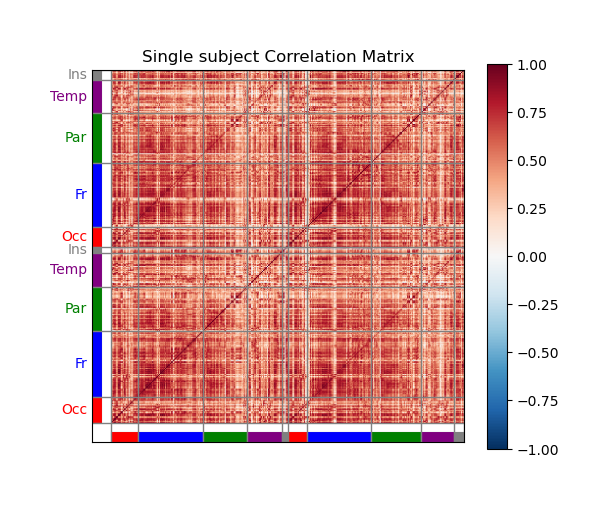

In [12]:
# Create a custom color bar for the groups
fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.imshow(correlation_matrix[0], vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks([])
ax.set_yticks([])

# Color bar for the matrix
plt.colorbar(cax, ax=ax)
plt.xlim(-20, )
plt.ylim(-20, 360)

# Add dividing lines for each group
for size in cumsum_sizes:
    ax.axhline(size - 0.5, color='gray', linewidth=1)
    ax.axvline(size - 0.5, color='gray', linewidth=1)

# Add colored rectangles for each group - x axis
for idx, color in enumerate(group_colors):
    rect = patches.Rectangle((-20, cumsum_sizes[idx] - 0.5), 10, lobe_sizes[idx], linewidth=0.1, edgecolor='gray', facecolor=color)
    ax.add_patch(rect)
    
# Add colored rectangles for each group - y axis
for idx, color in enumerate(group_colors):
    rect = patches.Rectangle((cumsum_sizes[idx] - 0.5, -20), lobe_sizes[idx], 10, linewidth=0.1, edgecolor='gray', facecolor=color)
    ax.add_patch(rect)

# Annotate group names
for idx, label in enumerate(lobe_list.tolist()*2):
    plt.text(-25, (cumsum_sizes[idx] + cumsum_sizes[idx + 1]) / 2, label, fontsize=10, va='center', 
             ha='right', color=group_colors[idx])

plt.title('Single subject Correlation Matrix')
plt.show()

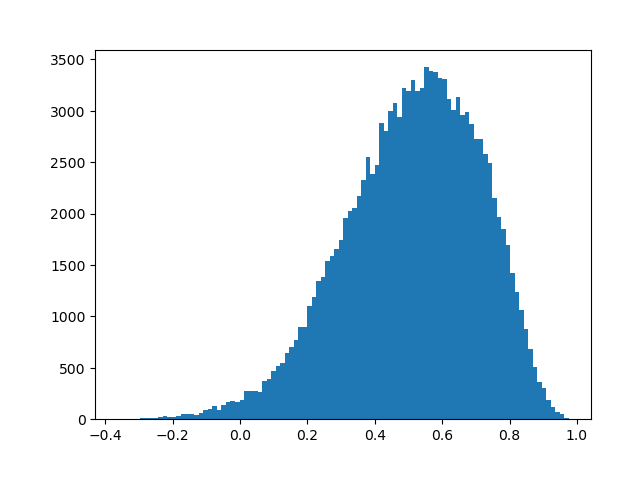

In [13]:
plt.hist(correlation_matrix[0][correlation_matrix[0]!=1].flatten(), bins=100);

In [40]:
# Set an arbitrary threshold to binarize the correlation matrix in order to create a graph
threshold = 0.75
adj_matrix = np.copy(correlation_matrix[0])
adj_matrix = np.abs(adj_matrix)
adj_matrix[np.where(adj_matrix>=threshold)] = 1
adj_matrix[np.where(adj_matrix<threshold)] = 0
np.fill_diagonal(adj_matrix, 0)

In [41]:
node_labels = atlas_labels['regionName'].values
n_nodes = len(node_labels)

In [42]:
# Make a matrix for pycirclize from adjacency matrix #
## Lobes version ##
# matrix_data = np.zeros((len(lobe_list),len(lobe_list)))
# for x_i, lobe_x in enumerate(lobe_list): # Loop over lobes
#     idxs_x = atlas_labels.loc[atlas_labels['Lobe']==lobe_x]['regionID'].index # Indexes of all the area of the current lobe
#     for y_i, lobe_y in enumerate([l for l in lobe_list if l!=lobe_x]): # Loop over lobes
#         idxs_y = atlas_labels.loc[atlas_labels['Lobe']==lobe_y]['regionID'].index # Indexes of all the area of the current lobe
#         # print(int(np.sum(adj_matrix[idxs_x][:,idxs_y])))
#         matrix_data[x_i,y_i] = int(np.sum(adj_matrix[idxs_x][:,idxs_y]))


## Corteces version ##
cortex_list = atlas_labels['cortex'].unique()
matrix_data = np.zeros((len(cortex_list),len(cortex_list)))
for x_i, cortex_x in enumerate(cortex_list): # Loop over cortices
    idxs_x = atlas_labels.loc[atlas_labels['cortex']==cortex_x]['regionID'].index # Indexes of all the area of the current cortex
    for y_i, cortex_y in enumerate([l for l in cortex_list if l!=cortex_x]): # Loop over cortices
        idxs_y = atlas_labels.loc[atlas_labels['cortex']==cortex_y]['regionID'].index # Indexes of all the area of the current cortex
        matrix_data[x_i,y_i] = int(np.sum(adj_matrix[idxs_x][:,idxs_y]))

np.fill_diagonal(matrix_data, 0)

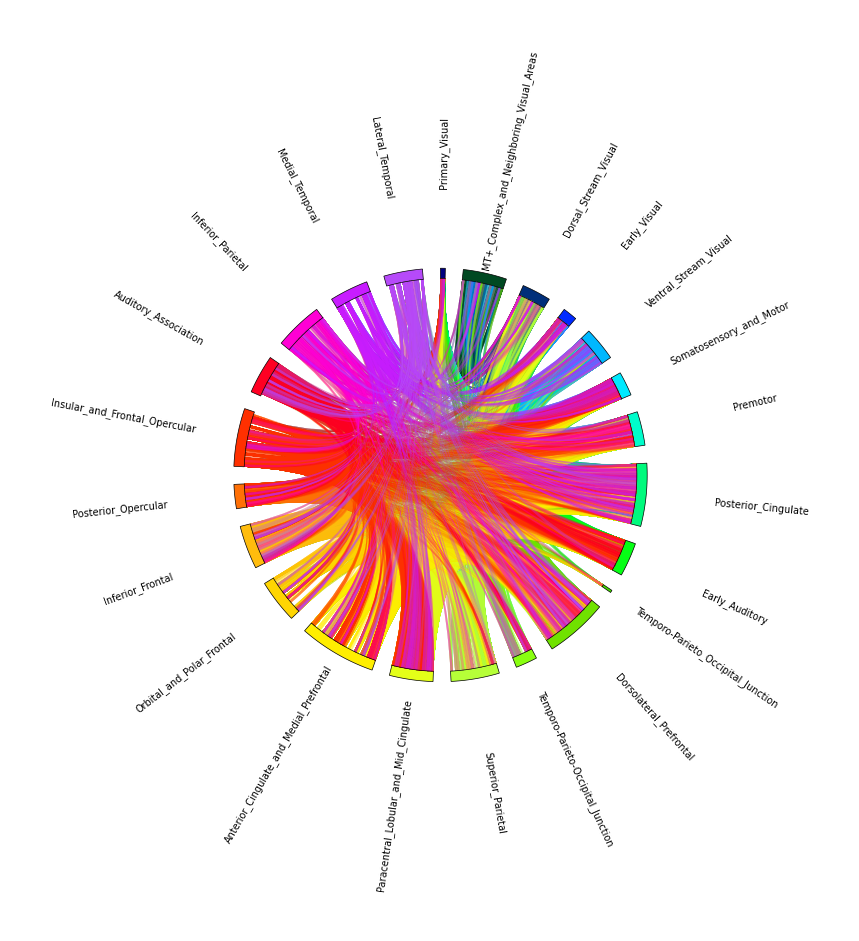

In [43]:
# Here we define each link, one by one

cortex_dict = {}
for cortex in cortex_list:
    cortex_dict[cortex] = int(np.sum(atlas_labels['cortex']==cortex))
cortex_cumsum = {}
prev=0
for cortex in cortex_dict.keys():
    cortex_cumsum[cortex]=prev
    prev+=cortex_dict[cortex]

# Use a pastel colormap from Matplotlib
cmap = plt.get_cmap('gist_ncar')

# Generate 23 unique pastel colors
colors = [cmap(i) for i in range(23*10)]

# Create a dictionary mapping each string to a pastel color
name2color = {cortex_list[i]: colors[i*10] for i in range(23)}
# find all the link 
links = []
for c_i,cortex in enumerate(cortex_list):
    idxs = atlas_labels[atlas_labels['cortex']==cortex].index # Indexes of all the regions in the current cortex
    for i,idx in enumerate(idxs): # Loop over all the regions in the current cortex
        for where in np.where(adj_matrix[idx])[0]: # loop over areas linked to the current area
            to_cortex = atlas_labels.iloc[where]['cortex']
            to_idx = np.where(atlas_labels[atlas_labels['cortex']==to_cortex].index==where)[0]
            from_idx = np.where(atlas_labels[atlas_labels['cortex']==cortex].index==idx)[0]
            links.append( [(cortex, from_idx[0], from_idx[0]+1 ), (to_cortex, to_idx[0], to_idx[0]+1), colors[c_i*10]] ) 

sectors = cortex_dict
circos = Circos(sectors, space=5)
for sector in circos.sectors:
    track = sector.add_track((95, 100))
    track.axis(fc=name2color[sector.name])
    track.text(sector.name, color="black", size=7, orientation='vertical', r=156,
               horizontalalignment='center', adjust_rotation=True, multialignment='right')
    # track.xticks_by_interval(1)

# Loop over all the links

# # Plot links in various styles
for link in links:
    circos.link(link[0], link[1], color=link[2], alpha=0.3)

circos.plotfig();

# How to properly threshold a correlation matrix?

### Percolation

https://www.frontiersin.org/journals/neuroscience/articles/10.3389/fnins.2017.00441/full

In [44]:
%%time
# Compute the size of the giant component and the average shortest path for each at each treshold value

shortest_paths = [] # Average shortest path for each threshold
sizes_giant_component = []
thresholds = np.arange(0,1,0.05)
for thresh in tqdm(thresholds): # Loop over the thresolds for the phase locking matrices
    # Devo thresholdare pure la matrice media
    abs_correlation_matrix = np.abs(np.copy(correlation_matrix[0])) # Takes the module of the correlation matrix
    abs_correlation_matrix[np.where(abs_correlation_matrix<thresh)] = 0 # Binarize the mean pl matrix according to the current thresh
    abs_correlation_matrix[np.where(abs_correlation_matrix>=thresh)] = 1 # Binarize the mean pl matrix according to the current thresh
    G = nx.from_numpy_array(abs_correlation_matrix) # Make a graph with networkx
    shortest_paths.append(graph_metrics('average_shortest_path', G)) # Compute the average shortest path for the current threshold value
    sizes_giant_component.append(graph_metrics('size_giant_component', G)) # Compute the size (iin numebr of nodes) of the giant component

100%|██████████| 20/20 [00:16<00:00,  1.19it/s]

CPU times: total: 16.2 s
Wall time: 16.8 s


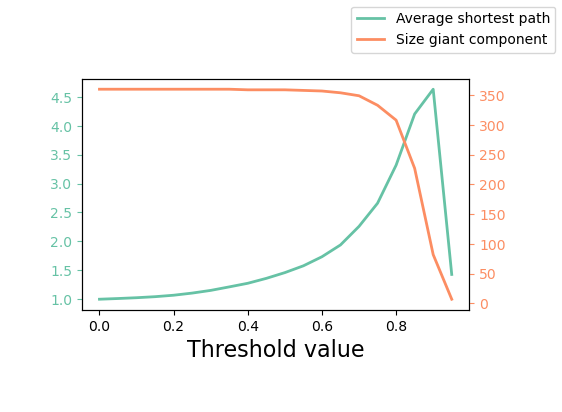

In [45]:
### Plot the results of the percolation analysis

cmap = matplotlib.colormaps['Set2']
colors = cmap(np.linspace(0, 1, 8))
fig, ax0 = plt.subplots(1, figsize=(5,3))
ax0.plot(thresholds, shortest_paths, alpha=1, linewidth=2, color=colors[0], label='Average shortest path')
ax0.set_xlabel('Threshold value', fontsize=16)
ax0.tick_params(colors=colors[0], axis='y')
ax1 = ax0.twinx()
ax1.plot(thresholds, sizes_giant_component, alpha=1, linewidth=2, color=colors[1],label='Size giant component')
ax1.yaxis.label.set_color(colors[1])
ax1.tick_params(colors=colors[1], axis='y')
fig.legend()

In [46]:
# # Set the optimal thrshold as the value corrisponding to the peak of the average shortest path as function of the thresold
opt_threshold = thresholds[np.argmax(shortest_paths)]
# # # Set the optimal thrshold as the value when the giant component starts breaking apart
# opt_threshold = thresholds[np.where(np.asarray(sizes_giant_component)!=360)[0][0]]
print(opt_threshold)

0.9


In [47]:
# Binarize the matrix
adj_matrix = np.copy(correlation_matrix[0])
adj_matrix = np.abs(adj_matrix)
adj_matrix[np.where(adj_matrix>=opt_threshold)] = 1
adj_matrix[np.where(adj_matrix<opt_threshold)] = 0
np.fill_diagonal(adj_matrix, 0)

In [48]:
# %%time
# # Plot the obtained adjacency matrix (if there are to many links this cell will take a lot of time)

# # Use a pastel colormap from Matplotlib
# cmap = plt.get_cmap('gist_ncar')

# # Generate 23 unique pastel colors
# colors = [cmap(i) for i in range(23*10)]

# # find all the link 
# links = []
# for c_i,cortex in enumerate(cortex_list):
#     idxs = atlas_labels[atlas_labels['cortex']==cortex].index # Indexes of all the regions in the current cortex
#     for i,idx in enumerate(idxs): # Loop over all the regions in the current cortex
#         for where in np.where(adj_matrix[idx])[0]: # loop over areas linked to the current area
#             to_cortex = atlas_labels.iloc[where]['cortex']
#             to_idx = np.where(atlas_labels[atlas_labels['cortex']==to_cortex].index==where)[0]
#             from_idx = np.where(atlas_labels[atlas_labels['cortex']==cortex].index==idx)[0]
#             links.append( [(cortex, from_idx[0], from_idx[0]+1 ), (to_cortex, to_idx[0], to_idx[0]+1), colors[c_i*10]] ) 

# sectors = cortex_dict
# circos = Circos(sectors, space=5)
# for sector in circos.sectors:
#     track = sector.add_track((95, 100))
#     track.axis(fc=name2color[sector.name])
#     track.text(sector.name, color="black", size=7, orientation='vertical', r=156,
#                horizontalalignment='center', adjust_rotation=True, multialignment='right')
#     # track.xticks_by_interval(1)

# # Loop over all the links

# # # Plot links in various styles
# for link in links:
#     circos.link(link[0], link[1], color=link[2], alpha=0.1)
# # circos.link(("A", 1, 2), ("A", 7, 6), color="skyblue")
# # circos.link(("A", 9, 10), ("B", 4, 3), direction=1, color="tomato")
# # circos.link(("B", 5, 7), ("C", 6, 8), direction=1, ec="black", lw=1, hatch="//")
# # circos.link(("B", 18, 16), ("B", 11, 13), r1=90, r2=90, color="violet", ec="red", lw=2, ls="dashed")
# # circos.link(("C", 1, 3), ("B", 2, 0), direction=1, color="limegreen")
# # circos.link(("C", 11.5, 14), ("A", 4, 3), direction=2, color="chocolate", ec="black", lw=1, ls="

# circos.plotfig();

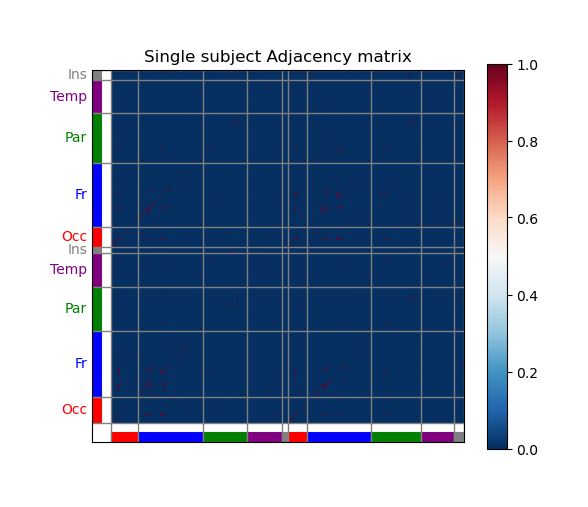

In [50]:
# Create a custom color bar for the groups
fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.imshow(adj_matrix, vmin=0, vmax=1, cmap='RdBu_r')
ax.set_xticks([])
ax.set_yticks([])

# Color bar for the matrix
plt.colorbar(cax, ax=ax)
plt.xlim(-20, )
plt.ylim(-20, 360)

# Add dividing lines for each group
for size in cumsum_sizes:
    ax.axhline(size - 0.5, color='gray', linewidth=1)
    ax.axvline(size - 0.5, color='gray', linewidth=1)

# Add colored rectangles for each group - x axis
for idx, color in enumerate(group_colors):
    rect = patches.Rectangle((-20, cumsum_sizes[idx] - 0.5), 10, lobe_sizes[idx], linewidth=0.1, edgecolor='gray', facecolor=color)
    ax.add_patch(rect)
    
# Add colored rectangles for each group - y axis
for idx, color in enumerate(group_colors):
    rect = patches.Rectangle((cumsum_sizes[idx] - 0.5, -20), lobe_sizes[idx], 10, linewidth=0.1, edgecolor='gray', facecolor=color)
    ax.add_patch(rect)

# Annotate group names
for idx, label in enumerate(lobe_list.tolist()*2):
    plt.text(-25, (cumsum_sizes[idx] + cumsum_sizes[idx + 1]) / 2, label, fontsize=10, va='center', 
             ha='right', color=group_colors[idx])

plt.title('Single subject Adjacency matrix')
plt.show()

## Global graph measures

In [51]:
# Binarize the matrix
opt_threshold = 0.9
adj_matrix = np.copy(correlation_matrix[0])
adj_matrix = np.abs(adj_matrix)
adj_matrix[np.where(adj_matrix>=opt_threshold)] = 1
adj_matrix[np.where(adj_matrix<opt_threshold)] = 0
np.fill_diagonal(adj_matrix, 0)

In [52]:
G = nx.from_numpy_array(adj_matrix) # Make a graph with networkx

Text(0, 0.5, 'Frequency')

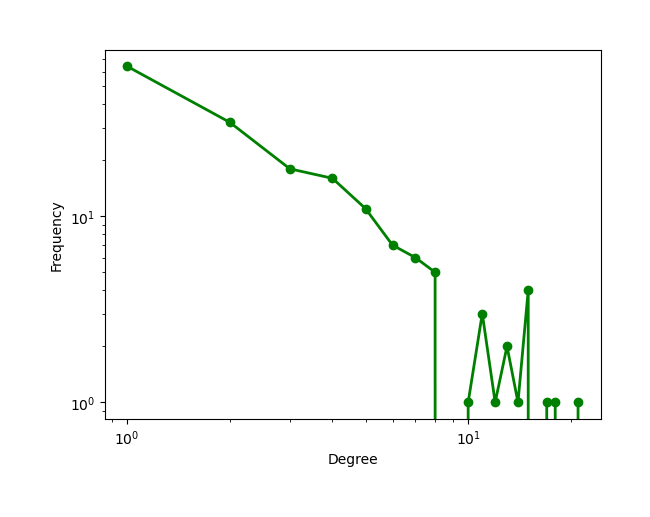

In [53]:
# Degree distribution
m=1
degree_freq = nx.degree_histogram(G)
degrees = range(len(degree_freq))
plt.figure() 
plt.loglog(degrees[m:], degree_freq[m:],'go-',linewidth=2) 
plt.xlabel('Degree')
plt.ylabel('Frequency')

In [54]:
nx.number_connected_components(G)

212

In [55]:
graph_metrics('global_efficiency',G)

0.018035096845449558

In [56]:
graph_metrics('average_shortest_path',G)

4.630834086118639

In [57]:
graph_metrics('modularity',G)

0.6945235552391124

In [58]:
graph_metrics('average_clustering', G)

0.15038161593308652

## Local graph measures

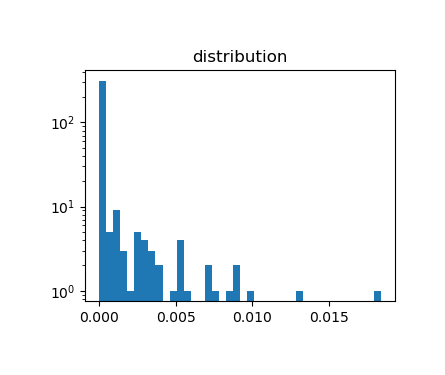

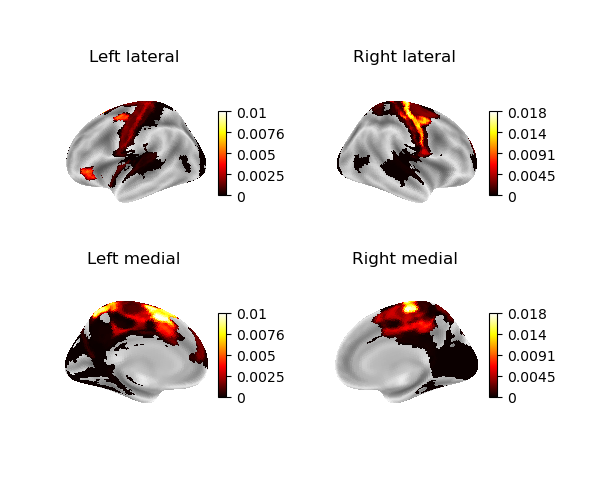

CPU times: total: 24.8 s
Wall time: 20.1 s


In [59]:
%%time
# Centrality measures - betweeness_centrality, clustering, local efficiency, degree_centrality
centralities = graph_metrics('betweeness_centrality',G)

# Plot the distribution of this measure across the brain
fig = plt.figure(figsize=(4,3))
plt.hist(centralities, bins=40);
plt.yscale('log')
plt.title('distribution')

brain_centralities = np.zeros((atlas.shape))
for area_i, area_c in enumerate(centralities):
    area_coord = np.where(atlas==area_i+1)
    brain_centralities[area_coord[0], area_coord[1], area_coord[2]] = area_c
nii_img = nib.Nifti1Image(brain_centralities, atlas_affine)

# Plot the betweenness centrality over the brain
fsaverage = datasets.fetch_surf_fsaverage()
texture_left = surface.vol_to_surf(nii_img, fsaverage.pial_left)
texture_left[np.where(texture_left==0)] = np.nan 
texture_right = surface.vol_to_surf(nii_img, fsaverage.pial_right)
texture_right[np.where(texture_right==0)] = np.nan 

cmap='hot'
fig, axs = plt.subplots(2,2,subplot_kw={'projection': '3d'})
# left hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            title='Left lateral', colorbar=True, view='lateral', axes=axs[0][0], cmap=cmap)
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            title='Left medial', colorbar=True, view='medial', axes=axs[1][0], cmap=cmap)
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            title='Right lateral', colorbar=True, view='lateral', axes=axs[0][1], cmap=cmap)
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            title='Right medial', colorbar=True, view='medial', axes=axs[1][1], cmap=cmap)


# Show the plot
plotting.show()

## Multiple subjects

## Load tha schaefer atlas

In [ ]:
main_path = '/content/'
file_name = 'schaefer_atlas.nii.gz'
file_name_labels = 'schaefer_labels.csv'
path = main_path+file_name
path_lab = main_path+file_name_labels

atlas_ = nib.load(path) # Load the nii.gz file of the subject
atlas_header = atlas_.header # Subject's header
atlas_affine = atlas_.affine # Subject's affine
atlas = atlas_.get_fdata() # Get the numpy version of the nii.gz file
print(atlas.shape) # x*y*z*time

# Labels
atlas_labels = pd.read_csv(path_lab, delimiter=';')
print(atlas.min(), atlas.max())

# Define a mask based on the atlas
atlas_mask = np.zeros(atlas.shape)
atlas_mask[np.where(atlas!=0)] = 1
atlas_mask_ = nib.Nifti1Image(atlas_mask, atlas_affine)

(60, 72, 60)
0.0 236.0


## Average functional connectivity between networks

In [ ]:
### Compute the Roi x Roi functional connectivity for all the subjects in the two conditions
# sub_list = ['01','03','04','05','06','07','08','09','10','11','12','13','14','15','16','17','18','19','20','22','23','24','25','26','27','28','29','30','31','32','33']
# sub_list = ['01','03','04','05','06','07','08','09','10','11']
sub_list = ['01','03','04','05','06']

network_list = atlas_labels['ROI_network'].unique()

main_path = '/content/'

rest_sleep_connectivity = []
rest_sleep_connectivity_network = []
for rest_or_sleep in ['rest','sleep']:
    all_sub_parc = [] # Concatenate here all the subjects
    for sub in sub_list: # Loop over the subjects
        print(sub)
        ## Load the subject
        file_name = 'sub_'+sub+'_'+rest_or_sleep+'.nii.gz'
        sub_ = nib.load(main_path+file_name) # Load the nii.gz file of the subject
        sub_header = sub_.header # Subject's header
        sub_affine = sub_.affine # Subject's affine
        sub = sub_.get_fdata() # Get the numpy version of the nii.gz file

        ## Parcel the brain - extract a time series from each roi
        sub_filtered_ = signal_filter(sub_, atlas_mask)
        sub_filtered = sub_filtered_.get_fdata()
        sub_parc = np.empty((0,sub.shape[-1])) # parcellized brain
        for a_idx in range(1, int(atlas.max())+1): # Loop over areas
            area_coord = np.where(atlas==a_idx) # coordinates of the current brain region
            area_ts = sub[area_coord].mean(axis=0) # time series of the current region
            sub_parc = np.concatenate((sub_parc, area_ts[np.newaxis]), axis=0)
        print(sub_parc.shape)
        all_sub_parc.append(sub_parc.T)
    # all_sub_parc = np.stack(all_sub_parc)
    # Compute the correlation matrix
    correlation_measure = ConnectivityMeasure(kind='correlation')
    correlation_matrix = correlation_measure.fit_transform(all_sub_parc)
    print(correlation_matrix.shape) 
    rest_sleep_connectivity.append(correlation_matrix)

    # Aggregate the rois per network
    correlation_matrix_network = np.zeros((len(sub_list), len(network_list), len(network_list)))
    for n_row, network in enumerate(network_list):
        idxs_row = atlas_labels.loc[atlas_labels['ROI_network']==network]['ROI_label'].values - 1
        for n_col, network in enumerate(network_list):
            idxs_col = atlas_labels.loc[atlas_labels['ROI_network']==network]['ROI_label'].values - 1
            correlation_matrix_network[:,n_row, n_col] = correlation_matrix[:,idxs_row][:,:,idxs_col].mean(axis=-1).mean(axis=-1) 
    rest_sleep_connectivity_network.append(correlation_matrix_network)

        

01
Filtering the signal...


100%|██████████| 41991/41991 [00:07<00:00, 5472.87it/s]


(236, 286)
03
Filtering the signal...


100%|██████████| 41991/41991 [00:07<00:00, 5496.17it/s]


(236, 286)
04
Filtering the signal...


...

(236, 429)
10
Filtering the signal...


100%|██████████| 41991/41991 [00:07<00:00, 5634.20it/s]


(236, 429)
11
Filtering the signal...


100%|██████████| 41991/41991 [00:08<00:00, 5158.47it/s]


(236, 429)
(10, 236, 236)


In [63]:
# t-test between network X network connectivities
from scipy.stats import ttest_ind, false_discovery_control

t_matrix = np.zeros((len(network_list), len(network_list)))
p_matrix = np.zeros((len(network_list), len(network_list)))
p_matrix_corrected = np.zeros((len(network_list), len(network_list)))

all_pvals = []
for n_row, network in enumerate(network_list):
    for n_col, network in enumerate(network_list):
        if n_col > n_row: # Take only the upper triangular matrix
            t, p = ttest_ind(rest_sleep_connectivity_network[0][:,n_row,n_col], rest_sleep_connectivity_network[1][:,n_row,n_col])
            t_matrix[n_row,n_col] = t
            p_matrix[n_row,n_col] = p
            all_pvals.append(p)
all_pvals_corrected = false_discovery_control(all_pvals)
count = 0
for n_row, network in enumerate(network_list):
    for n_col, network in enumerate(network_list):
        if n_col > n_row: # Take only the upper triangular matrix
            p_matrix_corrected[n_row,n_col] = all_pvals_corrected[count]
            count +=1


<Axes: >

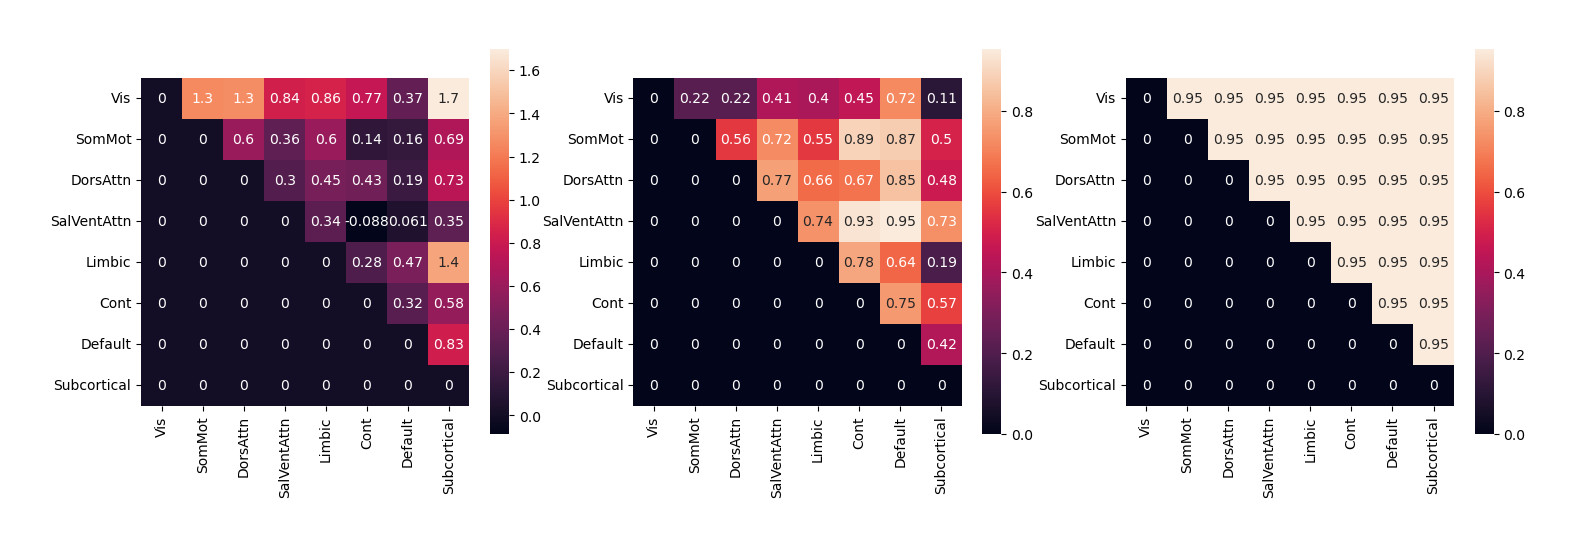

In [64]:
fig, axs = plt.subplots(1,3, figsize=(18,5))
sns.heatmap(t_matrix, annot=True, xticklabels=network_list, yticklabels=network_list, ax=axs[0], square=True)
sns.heatmap(p_matrix, annot=True, xticklabels=network_list, yticklabels=network_list, ax=axs[1], square=True)
sns.heatmap(p_matrix_corrected, annot=True, xticklabels=network_list, yticklabels=network_list, ax=axs[2], square=True)

## Graph-based measures: global integration in sleep and wakefulness

In [ ]:
### Compute the Roi x Roi functional connectivity for all the subjects in the two conditions
# sub_list = ['01','03','04','05','06','07','08','09','10','11','12','13','14','15','16','17','18','19','20','22','23','24','25','26','27','28','29','30','31','32','33']
# sub_list = ['01','03','04','05','06','07','08','09','10','11']
sub_list = ['01','03','04','05','06']

# sub_list = ['01','03']
network_list = atlas_labels['ROI_network'].unique()
threshold = 0.9

main_path = '/content/'
g_efficiencies = []
modularities = []
sleep_rest_list = []
for rest_or_sleep in ['rest','sleep']:
    all_sub_parc = [] # Concatenate here all the subjects
    for sub in sub_list: # Loop over the subjects
        print(sub)
        ## Load the subject
        file_name = 'sub_'+sub+'_'+rest_or_sleep+'.nii.gz'
        sub_ = nib.load(main_path+file_name) # Load the nii.gz file of the subject
        sub_header = sub_.header # Subject's header
        sub_affine = sub_.affine # Subject's affine
        sub = sub_.get_fdata() # Get the numpy version of the nii.gz file

        ## Parcel the brain - extract a time series from each roi
        sub_filtered_ = signal_filter(sub_, atlas_mask)
        sub_filtered = sub_filtered_.get_fdata()
        sub_parc = np.empty((0,sub.shape[-1])) # parcellized brain
        for a_idx in range(1, int(atlas.max())+1): # Loop over areas
            area_coord = np.where(atlas==a_idx) # coordinates of the current brain region
            area_ts = sub[area_coord].mean(axis=0) # time series of the current region
            sub_parc = np.concatenate((sub_parc, area_ts[np.newaxis]), axis=0)
        print(sub_parc.shape)
        all_sub_parc.append(sub_parc.T)
    # all_sub_parc = np.stack(all_sub_parc)
    # Compute the correlation matrix
    correlation_measure = ConnectivityMeasure(kind='correlation')
    correlation_matrix = correlation_measure.fit_transform(all_sub_parc)

    # Make a graph and measure the global integration for each subject
    for s,sub in enumerate(sub_list): # Loop over the subjects
        matrix = correlation_matrix[s]
        # threshold the correlation matrix
        matrix[matrix<threshold] = 0 # Binarize the mean pl matrix according to the current thresh
        matrix[matrix>=threshold] = 1 # Binarize the mean pl matrix according to the current thresh
        G = nx.from_numpy_array(matrix) # Make a graph with networkx
        g_efficiencies.append(graph_metrics('global_efficiency',G))
        modularities.append(graph_metrics('modularity',G))
        sleep_rest_list.append(rest_or_sleep)
    

01
Filtering the signal...


100%|██████████| 41991/41991 [00:07<00:00, 5497.12it/s]


(236, 286)
03
Filtering the signal...


100%|██████████| 41991/41991 [00:07<00:00, 5453.10it/s]


(236, 286)
04
Filtering the signal...


...

(236, 429)
10
Filtering the signal...


100%|██████████| 41991/41991 [00:09<00:00, 4272.84it/s]


(236, 429)
11
Filtering the signal...


100%|██████████| 41991/41991 [00:08<00:00, 4902.07it/s]


(236, 429)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

rest vs. sleep: t-test independent samples, P_val:4.266e-01 t=8.134e-01


C:\Users\alebo\AppData\Local\Temp\ipykernel_16100\4205182633.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(**hue_plot_params, ax=ax, width=0.6, inner="quart", linewidth=2)


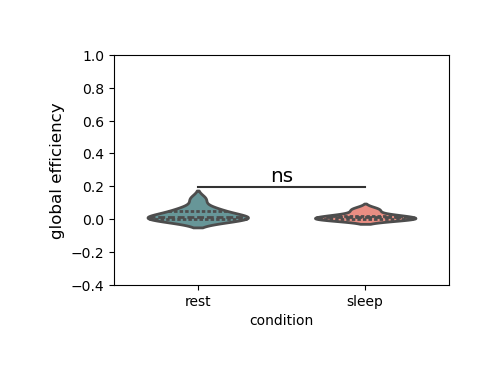

In [69]:
palette = {'sleep':'salmon', 'rest':'cadetblue'}
df_efficiency = pd.DataFrame({'global efficiency':g_efficiencies, 'condition':sleep_rest_list}) 
makeboxplot_1group(df_efficiency, palette, 'global efficiency', title='', ylim=[-0.4,+1], annot_test='t-test_ind')


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

rest vs. sleep: t-test independent samples, P_val:4.298e-01 t=-8.078e-01


C:\Users\alebo\AppData\Local\Temp\ipykernel_16100\4205182633.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(**hue_plot_params, ax=ax, width=0.6, inner="quart", linewidth=2)


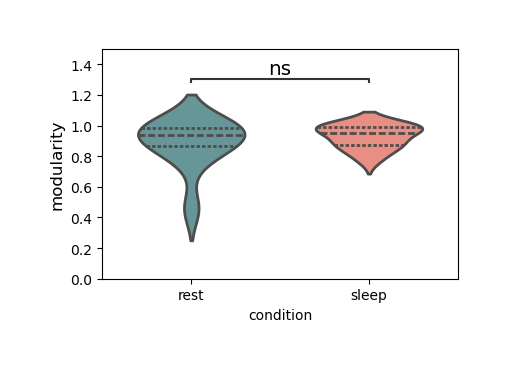

In [68]:
palette = {'sleep':'salmon', 'rest':'cadetblue'}
df_efficiency = pd.DataFrame({'modularity':modularities, 'condition':sleep_rest_list}) 
makeboxplot_1group(df_efficiency, palette, 'modularity', title='', ylim=[0,+1.5], annot_test='t-test_ind')